# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA as skPCA
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans, DBSCAN, MiniBatchKMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

from sklearn.metrics.cluster import adjusted_rand_score

In [3]:
df = pd.read_csv('data/RFM_base.csv')
df.set_index('customer_unique_id', inplace=True)

df

,recency,frequency,monetary,max_order_date
customer_unique_id,,,,
7c396fd4830fd04220f754e42b4e5bff,380,2,65.38,2017-10-02
af07308b275d755c9edb36a90c618231,85,1,118.70,2018-07-24
3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.90,2018-08-08
7c142cf63193a1473d2e66489a9ae977,333,1,45.00,2017-11-18
72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90,2018-02-13
...,...,...,...,...
6359f309b166b0196dbf7ad2ac62bb5a,587,1,72.00,2017-03-09
da62f9e57a76d978d02ab5362c509660,253,1,174.90,2018-02-06
737520a9aad80b3fbbdad19b66b37b30,416,1,205.99,2017-08-27


In [4]:
offset = -2
n_periods = 18

#list_offsets = [i for i in range(n_offset, n_periods+n_offset, n_offset)]
list_offsets = list(range(n_periods, 0, offset))
list_offsets

[18, 16, 14, 12, 10, 8, 6, 4, 2]

In [5]:
min_date = pd.to_datetime(df['max_order_date'].min())
max_date = pd.to_datetime(df['max_order_date'].max())

print(min_date.strftime('%Y-%m-%d'))
print(max_date.strftime('%Y-%m-%d'))

2016-09-04
2018-10-16


In [6]:
n_period_sp = 5
limit_date = (max_date - pd.DateOffset(weeks=list_offsets[n_period_sp])).strftime('%Y-%m-%d')

print (f"Date max {max_date.strftime('%Y-%m-%d')} après retrait de {n_period_sp} semaines : {limit_date}")

Date max 2018-10-16 après retrait de 5 semaines : 2018-08-21


In [7]:
dfs = {}

#list_n_df
#len_offsets = len(list_offsets)
#offsets_count = list(range(1, len_offsets, 1))
n = 1

for i in list_offsets:
    subset = df[df['max_order_date'] <= (max_date - pd.DateOffset(weeks=i)).strftime('%Y-%m-%d')]
    #dfs[f'df_{i}'] = subset
    dfs[f'df_{n}'] = subset
    n+=1

print(dfs.keys())

dict_keys(['df_1', 'df_2', 'df_3', 'df_4', 'df_5', 'df_6', 'df_7', 'df_8', 'df_9'])


In [8]:
for name, df in dfs.items():
    print(f'{name}:')
    print(df.shape)
    print(df['max_order_date'].max())
    print()

df_1:
(79210, 4)
2018-06-12

df_2:
(82089, 4)
2018-06-26

df_3:
(84448, 4)
2018-07-10

df_4:
(87348, 4)
2018-07-24

df_5:
(91157, 4)
2018-08-07

df_6:
(94724, 4)
2018-08-21

df_7:
(95412, 4)
2018-09-03

df_8:
(95414, 4)
2018-09-10

df_9:
(95418, 4)
2018-10-01



In [10]:
# drop max_order_date column
for name, df in dfs.items():
    df = df.drop('max_order_date', axis=1)
    dfs[name] = df

for name, df in dfs.items():
    print(f'{name}:')
    print(df.shape)
    print()

df_1:
(79210, 3)

df_2:
(82089, 3)

df_3:
(84448, 3)

df_4:
(87348, 3)

df_5:
(91157, 3)

df_6:
(94724, 3)

df_7:
(95412, 3)

df_8:
(95414, 3)

df_9:
(95418, 3)



In [11]:
dfs['df_1']

,recency,frequency,monetary
customer_unique_id,,,
7c396fd4830fd04220f754e42b4e5bff,380,2,65.38
7c142cf63193a1473d2e66489a9ae977,333,1,45.00
72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90
80bb27c7c16e8f973207a5086ab329e2,465,1,147.90
36edbb3fb164b1f16485364b6fb04c73,554,1,49.90
...,...,...,...
6359f309b166b0196dbf7ad2ac62bb5a,587,1,72.00
da62f9e57a76d978d02ab5362c509660,253,1,174.90
737520a9aad80b3fbbdad19b66b37b30,416,1,205.99


# train kmeans_8 all datasets


In [12]:
skewness = dfs['df_1'].select_dtypes(include=np.number).skew()
treshold_skew = 1.0
cols_skewed = skewness[skewness > treshold_skew].index.tolist()
cols_unskewed = skewness[skewness < treshold_skew].index.tolist()

print("Colonnes numériques avec une skewness supérieure à la limite :")
print(cols_skewed)
print(cols_unskewed)


Colonnes numériques avec une skewness supérieure à la limite :
['frequency', 'monetary']
['recency']


In [13]:
def customTransform(df, cols_skewed, cols_unskewed):
    # sélection colonnes avec skewness élevée :
    
    # Création du ColumnTransformer
    transformer = ColumnTransformer([
        #('minmax', MinMaxScaler(), cols_skewed),
        ('power', PowerTransformer(), cols_skewed),
        ('standard', StandardScaler(), cols_unskewed)
    ])
    
    X_std = pd.DataFrame(transformer.fit_transform(df), columns=df.columns)
    return X_std

In [27]:
# drop max_order_date column
X_stds = {}

for name, df in dfs.items():
    df = customTransform(df, cols_skewed, cols_unskewed)
    name_split = name.split("_")
    X_stds[f'X_{name_split[1]}'] = df

In [28]:
X_stds.keys()

dict_keys(['X_1', 'X_2', 'X_3', 'X_4', 'X_5', 'X_6', 'X_7', 'X_8', 'X_9'])

In [29]:
for name, df in X_stds.items():
    print(f'{name}:')
    print(df.shape)
    print()

X_1:
(79210, 3)

X_2:
(82089, 3)

X_3:
(84448, 3)

X_4:
(87348, 3)

X_5:
(91157, 3)

X_6:
(94724, 3)

X_7:
(95412, 3)

X_8:
(95414, 3)

X_9:
(95418, 3)



In [30]:
X_stds['X_1']

,recency,frequency,monetary
0,2.255141e-16,-0.281383,0.381262
1,-6.938894e-18,-0.697912,0.033674
2,-6.938894e-18,-1.644242,-0.609733
3,-6.938894e-18,0.586847,1.009878
4,-6.938894e-18,-0.581509,1.668075
...,...,...,...
79205,-6.938894e-18,-0.175749,1.912126
79206,-6.938894e-18,0.757850,-0.557965
79207,-6.938894e-18,0.922290,0.647499
79208,-6.938894e-18,1.465520,-0.343496


## Check training first dataset

BatchKmeans 2 clusters, sil score : 0.3585663618604743
BatchKmeans 3 clusters, sil score : 0.3735015061800348
BatchKmeans 4 clusters, sil score : 0.2977588793593463
BatchKmeans 5 clusters, sil score : 0.31316888934656495
BatchKmeans 6 clusters, sil score : 0.328670076409774
BatchKmeans 7 clusters, sil score : 0.3385220719609588
BatchKmeans 8 clusters, sil score : 0.3224640450308046
BatchKmeans 9 clusters, sil score : 0.3370484871048151
BatchKmeans 10 clusters, sil score : 0.330897794829022
BatchKmeans 11 clusters, sil score : 0.324749488392189
BatchKmeans 12 clusters, sil score : 0.32124940900945176
BatchKmeans 13 clusters, sil score : 0.3119705065814481
BatchKmeans 14 clusters, sil score : 0.3186043832319725
BatchKmeans 15 clusters, sil score : 0.3151188579949321


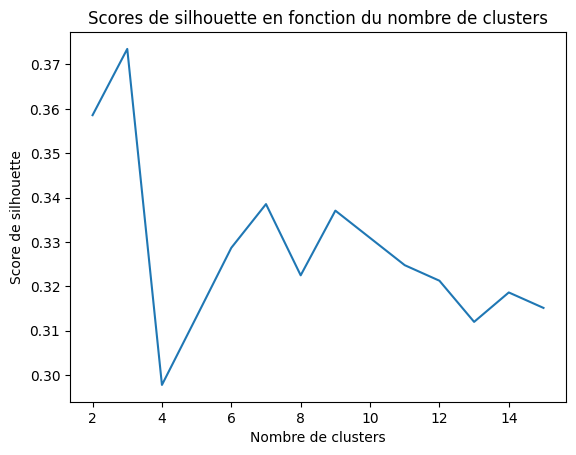

Le nombre optimal de clusters est : 3


In [18]:
X_std = X_stds['X_1'].copy()

# Calcul du score de silhouette pour chaque valeur de n_clusters comprise entre 2 et 15
n_clusters_range = range(2, 16)
scores = []

columns = X_std.columns

for n_clusters in n_clusters_range:
    # Initialisation de KMeans avec kmeans++
    
    #kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, random_state=42)
    #kmeans.fit(X_std)
    #labels = kmeans.labels_
    #score = silhouette_score(X_std, labels)
    #print(f'Kmeans sil score : {score}')
    #scores.append(score)

    # Initialisation de MiniBatchKMeans
    mbkmeans = MiniBatchKMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, batch_size=100, random_state=42)
    mbkmeans.fit(X_std)
    labels_mb = mbkmeans.labels_
    score_mb = silhouette_score(X_std, labels_mb)
    print(f'BatchKmeans {n_clusters} clusters, sil score : {score_mb}')
    scores.append(score_mb)

# Tracé du graphique des scores de silhouette
plt.plot(n_clusters_range, scores)
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de silhouette')
plt.title('Scores de silhouette en fonction du nombre de clusters')
plt.show()

# Sélection de la valeur de n_clusters qui donne le score de silhouette le plus élevé
best_score = max(scores)
best_index = scores.index(best_score)
best_n_clusters = best_index + 2

print(f"Le nombre optimal de clusters est : {best_n_clusters}")

In [22]:
sorted_scores = np.argsort(scores)[::-1]
top_indices = sorted_scores[:5]

print("Les 5 plus grands score de silhouette sont :")

for indice in top_indices:
    print(f"{indice+2} clusters pour {scores[indice]} score de silhouette")

Les 5 plus grands score de silhouette sont :
3 clusters pour 0.3735015061800348 score de silhouette
2 clusters pour 0.3585663618604743 score de silhouette
7 clusters pour 0.3385220719609588 score de silhouette
9 clusters pour 0.3370484871048151 score de silhouette
10 clusters pour 0.330897794829022 score de silhouette


In [19]:
inertia = {}
dict_kmeans = {}
for k in range(1,25):
    print(k)
    kmeans = KMeans(n_clusters=k,
                   verbose=1,
                   random_state=0
                   ).fit(X_std)
    inertia[k] = kmeans.inertia_
    dict_kmeans[k] = kmeans

1
Initialization complete
Iteration 0, inertia 213583.44268418744.
Iteration 1, inertia 158419.99999999977.
Converged at iteration 1: strict convergence.
2
Initialization complete
Iteration 0, inertia 124743.59486780426.
Iteration 1, inertia 107265.68597233422.
Iteration 2, inertia 107040.04987578026.
Iteration 3, inertia 106908.42451346818.
Iteration 4, inertia 106806.519456065.
Iteration 5, inertia 106702.1567664715.
Iteration 6, inertia 106594.66199494556.
Iteration 7, inertia 106486.02078677698.
Iteration 8, inertia 106362.81881628599.
Iteration 9, inertia 106225.82190594861.
Iteration 10, inertia 106042.91631769258.
Iteration 11, inertia 105814.49802975293.
Iteration 12, inertia 105555.13694153358.
Iteration 13, inertia 105248.42525193357.
Iteration 14, inertia 104868.650302383.
Iteration 15, inertia 104384.02538835975.
Iteration 16, inertia 103761.67678003955.
Iteration 17, inertia 103068.76472094088.
Iteration 18, inertia 102481.59527138685.
Iteration 19, inertia 102033.76807919

<AxesSubplot:title={'center':'Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters'}>

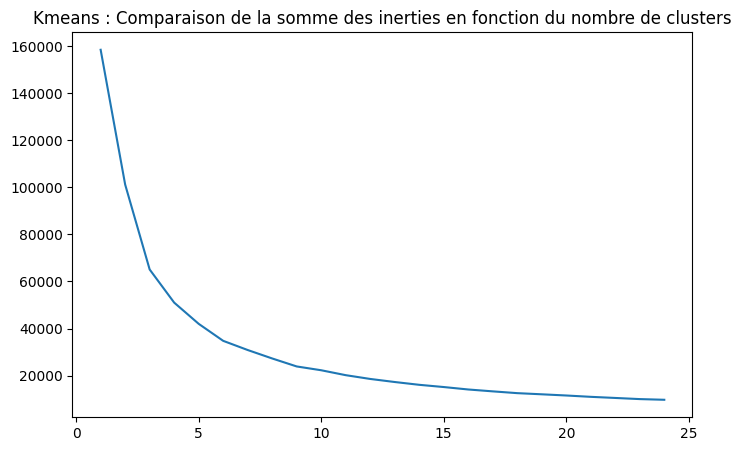

In [20]:
plt.figure(figsize=(8,5))
plt.title('Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters')
sns.lineplot(x=list(inertia.keys()),
             y=list(inertia.values())
            )

### Train and compare through time

In [31]:
clusters_num = 7

dict_Kmeans_X = {}

for name, df in X_stds.items():
    kmeans = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(df)
    dict_Kmeans_X[f'kmeans_{name}'] = kmeans

Initialization complete
Iteration 0, inertia 40787.253174168785.
Iteration 1, inertia 34127.90081533363.
Iteration 2, inertia 32478.34731464374.
Iteration 3, inertia 31774.07472927779.
Iteration 4, inertia 31426.61688121507.
Iteration 5, inertia 31250.086143507877.
Iteration 6, inertia 31118.892947692788.
Iteration 7, inertia 31051.562958562678.
Iteration 8, inertia 31016.905848468123.
Iteration 9, inertia 30994.35440653.
Iteration 10, inertia 30978.6430513189.
Iteration 11, inertia 30964.935397992722.
Iteration 12, inertia 30954.967901398613.
Iteration 13, inertia 30948.237274401257.
Iteration 14, inertia 30943.820911513238.
Iteration 15, inertia 30939.468956043587.
Iteration 16, inertia 30935.47990069896.
Iteration 17, inertia 30931.58720417072.
Iteration 18, inertia 30928.193209974765.
Iteration 19, inertia 30925.128534954638.
Iteration 20, inertia 30922.320254223643.
Iteration 21, inertia 30919.30441028805.
Iteration 22, inertia 30916.379520614668.
Iteration 23, inertia 30913.43653

# Compute ARI

In [67]:
scores = []
first_kmeans = dict_Kmeans_X['kmeans_X_1']

for name, kmeans in dict_Kmeans_X.items():
    X_name = name.replace("kmeans_", "")
    ari = adjusted_rand_score(kmeans.labels_, first_kmeans.predict(X_stds[X_name]))
    scores.append(ari)

#periodes = 

In [68]:
scores

[1.0,
 0.5254443515731712,
 0.6387511058079774,
 0.9334360883334516,
 0.5238079475758496,
 0.5235117201254338,
 0.5289786832808424,
 0.7867629968452026,
 0.7028365073972659]

In [73]:
scores_len = len(scores)
list_iter = list(range(0, scores_len, 1))

periodes = []

for i in list_iter:
    period_name = 
    periodes.append(period_name)

0
1
2
3
4
5
6
7
8


In [266]:
scores = [ari0, ari1, ari2, ari3, ari4, ari5, ari6]
periodes = ['Période 0', 'Période 1', 'Période 2', 'Période 3', 'Période 4', 'Période 5', 'Période 6']

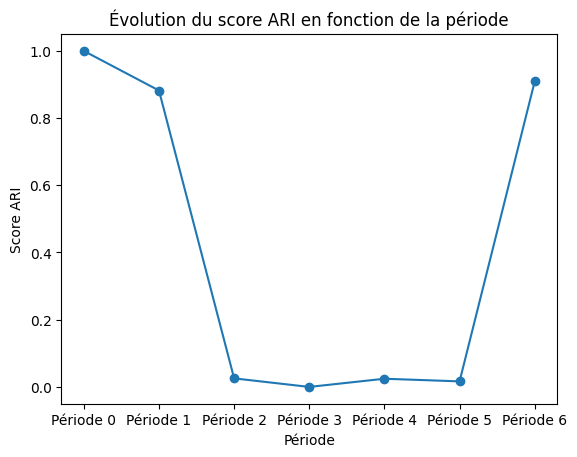

In [267]:
plt.plot(periodes, scores, marker='o')
plt.xlabel('Période')
plt.ylabel('Score ARI')
plt.title('Évolution du score ARI en fonction de la période')
plt.show()